# EDA song ngữ Trung–Việt (TMĐT) + Similarity bằng BAAI/bge-m3

**Input:** `bilingual_zh_vi.parquet` (~16K cặp sản phẩm TMĐT Trung–Việt)
**Mô hình:** [BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3) — gọi thẳng từ Hugging Face Hub qua thư viện `transformers`.
**Công cụ:** pandas + pyarrow (EDA) · transformers + torch (embedding)

> ⚠️ **Schema thực tế:** file **không** có cột `zh_text` / `vi_text` như giả định ban đầu.
> Các cột văn bản thực tế là `title_zh`, `title_vi`, `description_zh`, `description_vi`.
> Notebook tự động dò cột (auto-detect) nên chạy được với cả 2 kiểu schema.


In [1]:
# Cài thư viện (chỉ cần trên Colab / máy chưa có). Bỏ qua nếu đã cài.
%pip install -q transformers torch pandas pyarrow matplotlib


## 0. Cài đặt & Import


In [2]:
import re
import hashlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

# Nguồn dữ liệu: Hugging Face (đọc trực tiếp qua HTTPS).
# Muốn dùng file local thì đổi lại thành "bilingual_zh_vi.parquet".
HF_REPO = "ntquang0410/zh-vie_ecom"
HF_FILE = "data/snapshot/bilingual_zh_vi.parquet"
PARQUET_PATH = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main/{HF_FILE}"

print("pandas", pd.__version__, "| torch", torch.__version__)


pandas 2.2.3 | torch 2.11.0+cu128


## 1. Tổng quan (shape, dtypes, null)


In [3]:
def load_parquet(path):
    """Đọc parquet từ URL hoặc đường dẫn local, fallback duckdb nếu pandas lỗi."""
    try:
        return pd.read_parquet(path)
    except ImportError as e:
        print("pandas thiếu thư viện, fallback duckdb:", e)
    except Exception as e:
        print("pandas lỗi:", type(e).__name__, e)
    import duckdb
    return duckdb.sql(f"SELECT * FROM read_parquet('{path}')").df()

df = load_parquet(PARQUET_PATH)

print("shape:", df.shape)
print("\n--- dtypes ---")
print(df.dtypes.to_string())
print("\n--- 5 dòng đầu ---")
display(df.head())

# --- Đếm null / rỗng theo từng cột (%) ---
# Cột nested (list/struct như attributes_zh) khi astype(str) ra "[]" chứ không rỗng,
# nên phải loại chúng khỏi phép đếm "rỗng" để tránh báo sai.
def is_text_col(s):
    return pd.api.types.is_string_dtype(s) or s.dtype == object

def is_nested_col(s):
    return s.map(type).isin([list, dict]).any()

def null_report(frame):
    rows = []
    n = len(frame)
    for c in frame.columns:
        s = frame[c]
        n_null = int(s.isna().sum())
        n_empty = 0
        if is_text_col(s) and not is_nested_col(s):
            try:
                n_empty = int(s.fillna("").astype(str).str.strip().eq("").sum())
            except Exception:
                n_empty = 0
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "null_%": round(100 * n_null / n, 2),
            "empty_%": round(100 * n_empty / n, 2),
        })
    return pd.DataFrame(rows).sort_values("null_%", ascending=False)

null_df = null_report(df)
print("\n--- Null / rỗng theo cột (chỉ in cột có vấn đề) ---")
display(null_df[null_df["null_%"] > 0].reset_index(drop=True))
print("Số cột có null:", int((null_df["null_%"] > 0).sum()), "/", len(null_df))


shape: (16348, 30)

--- dtypes ---
product_id               object
title_zh                 object
title_vi                 object
description_zh           object
description_vi           object
category                 object
source_site              object
url                      object
crawl_time               object
worker                   object
keyword                  object
page                      int64
search_url               object
price                   float64
sales                   float64
province                 object
city                     object
biz_type                 object
shop                     object
is_ad                      bool
category_1688            object
category_id_1688         object
has_vi                     bool
attributes_zh            object
attributes_vi            object
n_attributes_zh           int64
n_attributes_vi           int64
n_attributes_aligned      int64
description_extra_zh     object
description_images        int64

--- 

,product_id,title_zh,title_vi,description_zh,description_vi,category,source_site,url,crawl_time,worker,...,category_1688,category_id_1688,has_vi,attributes_zh,attributes_vi,n_attributes_zh,n_attributes_vi,n_attributes_aligned,description_extra_zh,description_images
0,592582928262,轮胎刷 风口刷 轮毂刷发动机刷细节刷缝隙刷洗车清洁小毛刷洗车刷,"Bàn chải lốp, bàn chải cửa gió, bàn chải trung tâm, bàn chải động cơ, bàn ch...","材质: 超细纤维; 品牌: 柏尼士; 产地: 广州; 货号: 洗车刷子系列; 颜色: 1号竹柄刷, 2号圆头刷好, 3号黑色圆头刷, 4号小尖头刷, 5...",Chất liệu: sợi nhỏ; Thương hiệu: Perniz; Xuất xứ: Quảng Châu; Số mặt hàng: D...,auto,1688,https://detail.1688.com/offer/592582928262.html,2026-09-17T19:28:45+00:00,worker_nhat_anh,...,汽车清洁工具,124742030,True,"[{'name': '材质', 'values': ['超细纤维']}, {'name': '品牌', 'values': ['柏尼士']}, {'na...","[{'name': 'Chất liệu', 'values': ['sợi nhỏ']}, {'name': 'Xuất xứ', 'values':...",11,11,11,,12
1,741400188461,汽车座椅后背收纳袋可爱卡通车载垃圾桶创意多功能汽车内饰防踢垫,"Túi đựng đồ phía sau ghế ô tô, thùng rác ô tô hoạt hình dễ thương, đệm chống...","材质: 皮革; 功能: 防水, 抗压, 可定制, 带提手; 使用位置: 座椅后背; 适用汽车品牌: 通用; 品牌: 羽岑; 使用方式: 悬挂式; 加工定...","Chất liệu: Da; Chức năng: Chống nước, Chống nén, Có thể tùy chỉnh, Có tay cầ...",auto,1688,https://detail.1688.com/offer/741400188461.html,2026-09-17T19:29:06+00:00,worker_nhat_anh,...,车用置物袋/置物箱,1032116,True,"[{'name': '材质', 'values': ['皮革']}, {'name': '功能', 'values': ['防水', '抗压', '可定...","[{'name': 'Thương hiệu', 'values': ['Vũ Cen']}, {'name': 'Chất liệu', 'value...",17,17,17,,20
2,916030328790,汽车临时停车牌女挪车电话牌车载手机号码牌创意摆件装饰用品大全,Biển báo đỗ xe ô tô tạm thời Biển báo điện thoại di động ô tô biển số điện t...,材质: 塑料; 品牌: other/其他; 类型: 隐藏式; 产地: 义乌; 加工定制: 否; 尺寸: 15; 型号: 0003; 适用送礼场合: 其他...,Chất liệu: Nhựa; Thương hiệu: Khác/khác; Loại: Kiểu ẩn; Xuất xứ: Nghĩa Ô; Gi...,auto,1688,https://detail.1688.com/offer/916030328790.html,2026-09-17T19:29:27+00:00,worker_nhat_anh,...,临时停车牌,201327101,True,"[{'name': '材质', 'values': ['塑料']}, {'name': '品牌', 'values': ['other/其他']}, {...","[{'name': 'Thương hiệu', 'values': ['Khác/khác']}, {'name': 'Chất liệu', 'va...",15,15,15,,6
3,789617923790,厂家批发车载停车牌隐藏式挪车金属号码牌夜光创意摆件汽车用品,Nhà sản xuất bán buôn tấm đỗ xe ô tô ẩn tấm số kim loại di chuyển ô tô dạ qu...,材质: 金属; 功能: 夜光; 品牌: 登驿诺; 类型: 隐藏式; 产地: 中国地区; 加工定制: 是; 尺寸: 125*18mm; 型号: 汽车隐藏式...,Chất liệu: Kim loại; chức năng: Phát sáng trong bóng tối; Thương hiệu: Dengn...,auto,1688,https://detail.1688.com/offer/789617923790.html,2026-09-17T19:29:46+00:00,worker_nhat_anh,...,临时停车牌,201327101,True,"[{'name': '材质', 'values': ['金属']}, {'name': '功能', 'values': ['夜光']}, {'name'...","[{'name': 'Thương hiệu', 'values': ['Dengnuo']}, {'name': 'Chất liệu', 'valu...",16,16,16,,18
4,859282894083,汽车摆件五星红旗党旗车载装饰用品伸缩 小红旗汽车香水工厂代发,Đồ trang trí ô tô Cờ đỏ năm sao Cờ đảng Đồ trang trí ô tô có thể thu vào Nhà...,风格: 中国传统; 材质: 玻璃; 功能: 祝福; 品牌: santigo; 加工定制: 是; 是否专利货源: 否; 货号: 旗帜摆件; 颜色分类: 金...,Phong cách: Truyền thống Trung Quốc; Chất liệu: Thủy tinh; Chức năng: Chúc p...,auto,1688,https://detail.1688.com/offer/859282894083.html,2026-09-17T19:30:12+00:00,worker_nhat_anh,...,汽车摆件,125086011,True,"[{'name': '风格', 'values': ['中国传统']}, {'name': '材质', 'values': ['玻璃']}, {'nam...","[{'name': 'Chất liệu', 'values': ['Thủy tinh']}, {'name': 'Phong cách', 'val...",9,9,9,,17



--- Null / rỗng theo cột (chỉ in cột có vấn đề) ---


,column,dtype,null_%,empty_%
0,biz_type,object,16.50,16.50
1,sales,float64,3.32,0.00
2,city,object,0.10,0.10
3,province,object,0.01,0.01


Số cột có null: 4 / 30


## 2. Thống kê văn bản (độ dài ký tự & token)


Cột zh dùng để phân tích: title_zh
Cột vi dùng để phân tích: title_vi

--- Thống kê độ dài (ký tự) ---


,zh_chars,vi_chars
count,16348.0,16348.0
mean,31.2,125.0
std,2.7,23.8
min,3.0,5.0
50%,31.0,124.0
95%,36.0,164.0
99%,42.0,191.0
max,55.0,270.0


--- Thống kê token ước lượng ---


,zh_tokens,vi_tokens
count,16348.0,16348.0
mean,31.1,27.8
std,2.6,5.3
min,3.0,1.0
50%,30.0,28.0
95%,36.0,36.0
99%,41.0,43.0
max,48.0,63.0


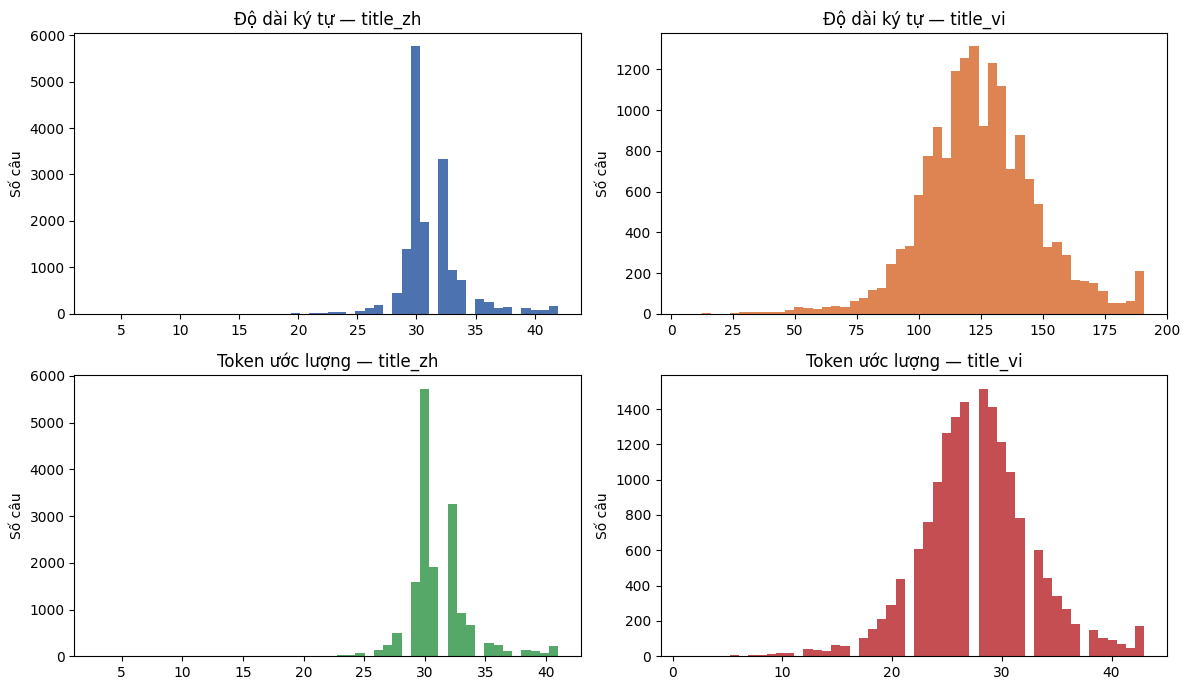


--- Tỷ lệ độ dài KÝ TỰ (vi/zh) ---
count    16348.000
mean         4.030
std          0.828
min          0.500
50%          4.000
95%          5.400
99%          6.333
max         10.077

--- Tỷ lệ TOKEN (vi_words / zh_chars) — dùng để phát hiện lệch ---
count    16348.000
mean         0.900
std          0.186
min          0.029
50%          0.900
95%          1.200
99%          1.414
max          2.192

Outlier theo tỷ lệ KÝ TỰ (>3.0 hoặc <0.3): 14906 (91.2%)  <- ngưỡng không phù hợp với zh->vi
Outlier theo tỷ lệ TOKEN  (>3.0 hoặc <0.3): 29 (0.18%)  <- dùng cái này


In [4]:
def is_flat_text(s):
    if not (pd.api.types.is_string_dtype(s) or s.dtype == object):
        return False
    return not s.map(type).isin([list, dict]).any()

def pick_col(frame, candidates):
    for c in candidates:
        if c in frame.columns and is_flat_text(frame[c]):
            return c
    return None

ZH_COL = pick_col(df, ["zh_text", "title_zh", "description_zh"])
VI_COL = pick_col(df, ["vi_text", "title_vi", "description_vi"])
print("Cột zh dùng để phân tích:", ZH_COL)
print("Cột vi dùng để phân tích:", VI_COL)

# Token ước lượng: tiếng Trung ~ 1 ký tự = 1 token; tiếng Việt ~ tách theo khoảng trắng
def est_tokens_zh(s):
    return s.fillna("").astype(str).str.replace(r"\s+", "", regex=True).str.len()

def est_tokens_vi(s):
    return s.fillna("").astype(str).str.split().str.len()

try:
    len_zh = df[ZH_COL].fillna("").astype(str).str.len()
    len_vi = df[VI_COL].fillna("").astype(str).str.len()
    tok_zh = est_tokens_zh(df[ZH_COL])
    tok_vi = est_tokens_vi(df[VI_COL])
except Exception as e:
    print("Lỗi tính độ dài:", e)
    len_zh = len_vi = tok_zh = tok_vi = pd.Series(dtype=float)

print("\n--- Thống kê độ dài (ký tự) ---")
display(pd.DataFrame({
    "zh_chars": len_zh.describe(percentiles=[.5, .95, .99]),
    "vi_chars": len_vi.describe(percentiles=[.5, .95, .99]),
}).round(1))

print("--- Thống kê token ước lượng ---")
display(pd.DataFrame({
    "zh_tokens": tok_zh.describe(percentiles=[.5, .95, .99]),
    "vi_tokens": tok_vi.describe(percentiles=[.5, .95, .99]),
}).round(1))

# --- Histogram cơ bản ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].hist(len_zh.clip(upper=len_zh.quantile(.99)), bins=50, color="#4C72B0")
axes[0, 0].set_title(f"Độ dài ký tự — {ZH_COL}")
axes[0, 1].hist(len_vi.clip(upper=len_vi.quantile(.99)), bins=50, color="#DD8452")
axes[0, 1].set_title(f"Độ dài ký tự — {VI_COL}")
axes[1, 0].hist(tok_zh.clip(upper=tok_zh.quantile(.99)), bins=50, color="#55A868")
axes[1, 0].set_title(f"Token ước lượng — {ZH_COL}")
axes[1, 1].hist(tok_vi.clip(upper=tok_vi.quantile(.99)), bins=50, color="#C44E52")
axes[1, 1].set_title(f"Token ước lượng — {VI_COL}")
for ax in axes.ravel():
    ax.set_ylabel("Số câu")
plt.tight_layout()
plt.show()

# --- Tỷ lệ độ dài zh/vi ---
# Tỷ lệ KÝ TỰ vi/zh luôn ~4.0 (tiếng Việt nhiều ký tự hơn) -> ngưỡng >3.0/<0.3 flag ~91%.
# => Dùng tỷ lệ TOKEN (số từ vi / số ký tự zh), kỳ vọng ~0.9.
ratio_char = (len_vi / len_zh.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
ratio_tok = (tok_vi / tok_zh.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

print("\n--- Tỷ lệ độ dài KÝ TỰ (vi/zh) ---")
print(ratio_char.describe(percentiles=[.5, .95, .99]).round(3).to_string())
print("\n--- Tỷ lệ TOKEN (vi_words / zh_chars) — dùng để phát hiện lệch ---")
print(ratio_tok.describe(percentiles=[.5, .95, .99]).round(3).to_string())

RATIO_HI, RATIO_LO = 3.0, 0.3
n_char_out = int(((ratio_char > RATIO_HI) | (ratio_char < RATIO_LO)).sum())
n_tok_out = int(((ratio_tok > RATIO_HI) | (ratio_tok < RATIO_LO)).sum())
print(f"\nOutlier theo tỷ lệ KÝ TỰ (>{RATIO_HI} hoặc <{RATIO_LO}): {n_char_out} "
      f"({100*n_char_out/len(df):.1f}%)  <- ngưỡng không phù hợp với zh->vi")
print(f"Outlier theo tỷ lệ TOKEN  (>{RATIO_HI} hoặc <{RATIO_LO}): {n_tok_out} "
      f"({100*n_tok_out/len(df):.2f}%)  <- dùng cái này")


## 3. Từ vựng & thuật ngữ TMĐT


In [5]:
# --- Top 30 token phổ biến mỗi ngôn ngữ (lowercase + strip) ---
def top_tokens(series, n=30, lang="vi"):
    txt = series.fillna("").astype(str).str.lower().str.strip()
    if lang == "zh":
        # tiếng Trung: tách theo ký tự Hán (bỏ khoảng trắng & dấu câu)
        toks = txt.str.findall(r"[\u4e00-\u9fff]")
    else:
        toks = txt.str.findall(r"\w+", flags=re.UNICODE)
    cnt = Counter(t for row in toks for t in row)
    return pd.DataFrame(cnt.most_common(n), columns=["token", "count"])

try:
    print(f"--- Top 30 token ZH ({ZH_COL}) ---")
    display(top_tokens(df[ZH_COL], 30, "zh"))
    print(f"--- Top 30 token VI ({VI_COL}) ---")
    display(top_tokens(df[VI_COL], 30, "vi"))
except Exception as e:
    print("Lỗi thống kê từ vựng:", e)

# --- Ký tự HTML còn sót ---
HTML_PATTERNS = {
    "entity (&amp; &lt; &gt; &quot; &#...);": r"&(?:amp|lt|gt|quot|nbsp|#\d+);",
    "tag (<...>)": r"<[^>]{1,80}>",
    "url (http/https)": r"https?://",
}
print("\n--- Ký tự HTML / URL còn sót ---")
rows = []
for name, pat in HTML_PATTERNS.items():
    for col in [c for c in [ZH_COL, VI_COL] if c]:
        try:
            n = int(df[col].fillna("").astype(str).str.contains(pat, regex=True).sum())
        except Exception:
            n = -1
        rows.append({"pattern": name, "column": col, "rows": n})
display(pd.DataFrame(rows))

# --- Thuật ngữ TMĐT ---
ZH_TERMS = ["包邮", "正品", "代购", "旗舰店", "促销", "折扣"]
VI_TERMS = ["freeship", "chính hãng", "khuyến mãi", "giảm giá", "ship", "sale"]

def count_terms(frame, terms, cols):
    out = []
    for t in terms:
        row = {"term": t}
        for c in cols:
            if c is None:
                continue
            try:
                row[c] = int(frame[c].fillna("").astype(str).str.lower()
                             .str.contains(re.escape(t.lower()), regex=True).sum())
            except Exception:
                row[c] = -1
        out.append(row)
    return pd.DataFrame(out)

print("\n--- Thuật ngữ TMĐT tiếng Trung ---")
ZH_TEXT_COLS = [c for c in df.columns if c.endswith("_zh") and is_flat_text(df[c])]
display(count_terms(df, ZH_TERMS, ZH_TEXT_COLS))
print("--- Thuật ngữ TMĐT tiếng Việt ---")
VI_TEXT_COLS = [c for c in df.columns if c.endswith("_vi") and is_flat_text(df[c])]
display(count_terms(df, VI_TERMS, VI_TEXT_COLS))


--- Top 30 token ZH (title_zh) ---


,token,count
0,包,9628
1,鞋,7453
2,款,6978
3,新,6236
4,女,5634
5,男,5522
6,套,4301
7,衣,3765
8,面,3729
9,茶,3671


--- Top 30 token VI (title_vi) ---


,token,count
0,cho,7287
1,giày,6392
2,đồ,5509
3,mới,5049
4,túi,4972
5,áo,4793
6,bộ,4715
7,nam,4539
8,nữ,4479
9,và,4469



--- Ký tự HTML / URL còn sót ---


,pattern,column,rows
0,entity (&amp; &lt; &gt; &quot; &#...);,title_zh,0
1,entity (&amp; &lt; &gt; &quot; &#...);,title_vi,0
2,tag (<...>),title_zh,0
3,tag (<...>),title_vi,0
4,url (http/https),title_zh,0
5,url (http/https),title_vi,0



--- Thuật ngữ TMĐT tiếng Trung ---


,term,title_zh,description_zh,attributes_zh,description_extra_zh
0,包邮,57,20,20,59
1,正品,214,22,22,91
2,代购,4,0,0,11
3,旗舰店,35,7,7,9
4,促销,1,77,77,34
5,折扣,1,0,0,29


--- Thuật ngữ TMĐT tiếng Việt ---


,term,title_vi,description_vi,attributes_vi
0,freeship,0,0,0
1,chính hãng,263,77,77
2,khuyến mãi,5,68,68
3,giảm giá,14,21,21
4,ship,95,90,90
5,sale,1,5,5


## 4. Trùng lặp


In [6]:
# LƯU Ý: df.duplicated() trên TOÀN BỘ frame sẽ lỗi nếu có cột nested (list/struct)
# như attributes_zh / attributes_vi -> phải giới hạn ở các cột văn bản.
TEXT_COLS = [c for c in [ZH_COL, VI_COL] if c]
PAIR_COLS = [c for c in ["title_zh", "title_vi", "description_zh", "description_vi"] if c in df.columns]

def dup_count(frame, cols, label):
    try:
        n = int(frame[cols].duplicated(keep="first").sum())
    except Exception as e:
        n = -1
        print(f"  ! {label}: {e}")
    print(f"{label:<42} {n:>7}  ({100*n/len(frame):.2f}%)")
    return n

print("--- Đếm trùng lặp ---")
dup_pair = dup_count(df, TEXT_COLS, f"Cặp trùng chính xác {TEXT_COLS}")
dup_full = dup_count(df, PAIR_COLS, "Trùng toàn bộ 4 cột văn bản")
dup_zh = dup_count(df, [ZH_COL], f"Câu ZH trùng ({ZH_COL})")
dup_vi = dup_count(df, [VI_COL], f"Câu VI trùng ({VI_COL})")
if "product_id" in df.columns:
    dup_count(df, ["product_id"], "product_id trùng")

# Kiểm chứng bằng hashlib (md5) trên cặp câu -> phải khớp với df.duplicated()
try:
    h = (df[ZH_COL].fillna("").astype(str) + "\x1f" + df[VI_COL].fillna("").astype(str)) \
        .map(lambda s: hashlib.md5(s.encode("utf-8")).hexdigest())
    print(f"\nHash md5 trùng (kiểm chứng): {int(h.duplicated().sum())}  "
          f"-> khớp với df.duplicated(): {int(h.duplicated().sum()) == dup_pair}")
except Exception as e:
    print("Lỗi hash:", e)

if dup_pair > 0:
    print("\n--- Ví dụ cặp trùng ---")
    display(df[df[TEXT_COLS].duplicated(keep=False)].sort_values(TEXT_COLS).head(6))


--- Đếm trùng lặp ---
Cặp trùng chính xác ['title_zh', 'title_vi']     211  (1.29%)
Trùng toàn bộ 4 cột văn bản                      7  (0.04%)
Câu ZH trùng (title_zh)                        485  (2.97%)
Câu VI trùng (title_vi)                        217  (1.33%)
product_id trùng                                 0  (0.00%)

Hash md5 trùng (kiểm chứng): 211  -> khớp với df.duplicated(): True

--- Ví dụ cặp trùng ---


,product_id,title_zh,title_vi,description_zh,description_vi,category,source_site,url,crawl_time,worker,...,category_1688,category_id_1688,has_vi,attributes_zh,attributes_vi,n_attributes_zh,n_attributes_vi,n_attributes_aligned,description_extra_zh,description_images
5961,898564855686,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 涤纶（聚酯纤维）; 面料名称: 纯棉; 款式: 套头; 工艺: 印花/印染; 适合人群: 青少年; 类别: 短袖T恤; 风格: 港风; 货...,Thành phần vải chính: Polyester (sợi polyester); Tên vải: 100% cotton; Kiểu ...,fashion,1688,https://detail.1688.com/offer/898564855686.html,2026-09-20T05:23:12+00:00,worker_huy,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['涤纶（聚酯纤维）']}, {'name': '面料名称', 'values': ['纯棉'...","[{'name': 'Phong cách', 'values': ['Phong cách Hồng Kông']}, {'name': 'Số mặ...",33,33,33,,9
5967,899141990675,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 涤纶（聚酯纤维）; 面料名称: 纯棉; 款式: 套头; 工艺: 印花/印染; 适合人群: 青少年; 类别: 短袖T恤; 风格: 港风; 货...,Thành phần vải chính: Polyester (sợi polyester); Tên vải: 100% cotton; Kiểu ...,fashion,1688,https://detail.1688.com/offer/899141990675.html,2026-09-20T05:24:09+00:00,worker_huy,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['涤纶（聚酯纤维）']}, {'name': '面料名称', 'values': ['纯棉'...","[{'name': 'Phong cách', 'values': ['Phong cách Hồng Kông']}, {'name': 'Số mặ...",33,33,33,,13
8961,899700624386,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 纯棉; 面料名称: 纯棉; 款式: 套头; 品牌: 其他; 工艺: 印花/印染; 适合人群: 青少年; 类别: 圆领T恤; 风格: 港风;...,Thành phần vải chính: 100% cotton1; Tên vải: 100% cotton2; Kiểu dáng: Chui đ...,fashion,1688,https://detail.1688.com/offer/899700624386.html,2026-09-20T04:35:41+00:00,worker_nhat_anh,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['纯棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'...","[{'name': 'Phong cách', 'values': ['Phong cách Hồng Kông']}, {'name': 'Số mặ...",37,37,37,,7
9393,901099727232,100%纯棉春夏装痞帅情侣装男复古港味ins字母短袖T恤新款宽松半袖,100% cotton quần áo mùa xuân và mùa hè quần áo cặp đôi đẹp trai áo phông ngắ...,主面料成分: 棉; 面料名称: 纯棉; 款式: 套头; 品牌: 渝泽服装厂; 工艺: 印花/印染; 适合人群: 青年; 类别: 短袖T恤; 风格: 国潮...,Thành phần vải chính: Bông; Tên vải: 100% cotton; Kiểu dáng: Chui đầu; Thươn...,fashion,1688,https://detail.1688.com/offer/901099727232.html,2026-09-20T07:18:58+00:00,worker_nhat_anh,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'n...","[{'name': 'Phong cách', 'values': ['Quốc triều']}, {'name': 'Số mặt hàng', '...",33,33,33,,12
6078,903729007320,100%纯棉百搭短袖t恤男2026新款夏季潮牌小众高街美式宽松上衣ins,"Áo thun nam tay ngắn 100% cotton nguyên chất, đa năng, thời trang hè 2026, t...",主面料成分: 棉; 面料名称: 纯棉; 款式: 套头; 品牌: 其他; 工艺: 免烫处理; 适合人群: 大码; 类别: T恤背心; 风格: 基础大众; ...,Thành phần vải chính: Bông; Tên vải: 100% cotton; Kiểu dáng: Chui đầu; Thươn...,fashion,1688,https://detail.1688.com/offer/903729007320.html,2026-09-20T07:07:00+00:00,worker_huy,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'n...","[{'name': 'Phong cách', 'values': ['Volkswagen cơ bản']}, {'name': 'Số mặt h...",37,37,37,,37
9002,897952027974,100%纯棉百搭短袖t恤男2026新款夏季潮牌小众高街美式宽松上衣ins,"Áo thun nam tay ngắn 100% cotton nguyên chất, đa năng, thời trang hè 2026, t...",主面料成分: 棉; 面料名称: 纯棉; 款式: 套头; 品牌: 其他; 工艺: 印花/印染; 适合人群: 青少年; 类别: T恤背心; 风格: 基础大众...,Thành phần vải chính: bông; Tên vải: bông nguyên chất; phong cách: áo thun1;...,fashion,1688,https://detail.1688.com/offer/897952027974.html,2026-09-20T04:52:22+00:00,worker_nhat_anh,...,男式T恤,315,True,"[{'name': '主面料成分', 'values': ['棉']}, {'name': '面料名称', 'values': ['纯棉']}, {'n...","[{'name': 'phong cách', 'values': ['Khối lượng cơ bản']}, {'name': 'phong cá...",36,36,36,,11


## 5. Similarity Trung–Việt bằng BAAI/bge-m3 (từ Hugging Face)

Gọi thẳng mô hình `BAAI/bge-m3` từ Hugging Face Hub qua thư viện `transformers`
(`AutoTokenizer` + `AutoModel`), dùng **CLS pooling** + **chuẩn hoá L2** (đúng theo
`1_Pooling/config.json`) → cosine similarity = tích vô hướng.


In [7]:
# --- Nạp bge-m3 thẳng từ Hugging Face Hub ---
MODEL_NAME = "BAAI/bge-m3"

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print("Thiết bị:", DEVICE)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

def encode(texts, max_length=512, batch_size=64):
    """Encode danh sách văn bản -> tensor (n, 1024) đã chuẩn hoá L2."""
    if isinstance(texts, str):
        texts = [texts]
    texts = ["" if t is None else str(t) for t in texts]
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = model(**enc)
        # CLS pooling (đúng cấu hình bge-m3)
        e = out.last_hidden_state[:, 0, :]
        e = F.normalize(e, p=2, dim=1)
        embs.append(e.cpu())
    return torch.cat(embs, dim=0)


Thiết bị: cuda


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 2.27GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

In [8]:
# --- Tính similarity cho tiêu đề (title_zh vs title_vi) ---
# SAMPLE = None để chạy toàn bộ 16K cặp (CPU ~ vài phút). Đặt số để chạy demo nhanh.
SAMPLE = 2000

work = df[[ZH_COL, VI_COL]].copy()
work[ZH_COL] = work[ZH_COL].fillna("").astype(str)
work[VI_COL] = work[VI_COL].fillna("").astype(str)
if SAMPLE:
    work = work.sample(SAMPLE, random_state=42)

zh_emb = encode(work[ZH_COL].tolist())
vi_emb = encode(work[VI_COL].tolist())
sim = (zh_emb * vi_emb).sum(dim=1)  # cosine = dot product (đã chuẩn hoá)
work["sim_score"] = sim.numpy()

print("--- Phân bố similarity bge-m3 (title) ---")
print(work["sim_score"].describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())

# Gắn sim_score về df gốc (theo index) để dùng ở phần xuất báo cáo
df["sim_score"] = np.nan
df.loc[work.index, "sim_score"] = work["sim_score"]

SIM_THRESHOLD = 0.5
print(f"\nSố cặp similarity < {SIM_THRESHOLD}: "
      f"{int((work['sim_score'] < SIM_THRESHOLD).sum())} "
      f"({100*(work['sim_score'] < SIM_THRESHOLD).mean():.2f}%)")

print("\n--- 20 cặp similarity thấp nhất (nghi dịch lệch) ---")
display(work.nsmallest(20, "sim_score")[[ZH_COL, VI_COL, "sim_score"]])

print("\n--- 5 cặp similarity cao nhất (dịch khớp tốt) ---")
display(work.nlargest(5, "sim_score")[[ZH_COL, VI_COL, "sim_score"]])


--- Phân bố similarity bge-m3 (title) ---
count    2000.000
mean        0.704
std         0.055
min         0.475
5%          0.608
25%         0.669
50%         0.707
75%         0.744
95%         0.786
max         0.924

Số cặp similarity < 0.5: 2 (0.10%)

--- 20 cặp similarity thấp nhất (nghi dịch lệch) ---


,title_zh,title_vi,sim_score
10391,凤凰单枞鸭屎香茶叶高端罐装特级老丛地标认证潮州单丛茶散批代发,"Trà Phượng Hoàng Đan Công Yashixiang, trà cao cấp đóng hộp, được chứng nhận ...",0.474828
6388,家城沙嗲素牛肉干怀旧辣条牛肉粒儿时经典校园素肉沙爹素小吃零食,"Thịt bò khô sa tế Jiacheng, thịt bò cay hoài cổ, món ăn nhẹ sa tế",0.494015
10172,福建武夷山红茶批发散装红茶茶叶浓香正山小种 金骏眉滇红茶厂家,"Trà đen núi Wuyi Phúc Kiến bán buôn, trà đen lá rời, hương thơm mạnh mẽ, Zhe...",0.518351
5353,泊泉雅木瓜净颜美肤洁面乳 泡沫绵密洁净柔和清爽滋润保湿 洗面奶,Sữa rửa mặt làm sạch và làm đẹp bằng đu đủ Boquanya,0.541155
5032,贝玲美原B5积雪草精粹焕颜面膜补水舒缓修护改善暗美妆护肤品面膜,"Mặt nạ dưỡng ẩm, làm dịu, sửa chữa và cải thiện vẻ đẹp tối, mặt nạ dưỡng da",0.542249
9901,柠檬酸辣无骨鸡爪2斤罐装代发酸辣泡椒蒜香无骨鸡爪冷冻整箱批发,Chân gà không xương chua cay 2 con đóng hộp thay thế tiêu chua cay chân gà k...,0.542769
10215,正品白毫银针新茶花香浓郁正宗云南古树白茶明前芽头白茶散茶罐装,"Trà Bạch Hào Ngân Châm chính hãng, trà mới, hương hoa nồng nàn, trà trắng cổ...",0.548424
4867,若水兰婷玻尿酸水光面膜贴补水保湿美容院同款面膜贴一件代发,Ruoshui Lanting Hyaluronic Acid Water Light Mask Patch Dưỡng ẩm cho Thẩm mỹ ...,0.548473
4903,泊蝶玻尿酸面膜 补水保湿批发保湿积雪草清洁泥膜复活草面膜贴女,"Mặt nạ Hyaluronic Acid Bodie cấp ẩm và dưỡng ẩm, bán buôn mặt nạ bùn làm sạc...",0.549243
6733,茶颜悦色柠檬茉莉玫瑰同款蜜桃乌龙茶花果茶批发,Trà Yanyuese chanh hoa nhài hoa hồng cùng loại trà đào ô long trà hoa quả bá...,0.549384



--- 5 cặp similarity cao nhất (dịch khớp tốt) ---


,title_zh,title_vi,sim_score
6790,Gaba Dahongpao tea Габа чай 嘎巴大红袍乌龙茶,Trà Gaba Dahongpao Trà Gaba 嘎巴大红袍乌龙茶,0.923649
15107,Minitutu儿童PPSU水杯翻盖奶瓶330mL宝宝学饮杯9个月以上好吸防呛,Bình nước PPSU lật nắp cho trẻ em Minitutu 330mL cốc uống nước học tập cho b...,0.853965
5836,hello简约英文适用于iPhone16Pro苹果手机壳耐脏全包防毛皮软壳,Ốp điện thoại iPhone 16Pro dùng cho iPhone đơn giản tiếng Anh hello ốp mềm c...,0.849376
13538,PLOVER减震运动板鞋男2026新款潮流百搭休闲鞋轻便软底防滑运动鞋,"Giày thể thao nam PLOVER giảm chấn, mẫu mới 2026, phong cách thời trang, dễ ...",0.845661
14710,Minitutu学饮杯PPSU奶瓶水杯6月以上1岁宝宝宽口径儿童水杯厂家批,Cốc uống nước học tập Minitutu Bình nước PPSU cho bé trên 6 tháng và 1 tuổi ...,0.843348


## 6. Kiểm tra căn chỉnh (heuristic token-ratio)

Bổ sung cho similarity: heuristic tỷ lệ độ dài token để bắt các cặp "lệch căn chỉnh"
do bản dịch bị thiếu/thừa/trộn dòng.


In [9]:
# --- Heuristic phát hiện cặp câu nghi lệch căn chỉnh ---
# KHÔNG dùng \W để phát hiện "toàn ký tự đặc biệt" cho tiếng Trung:
# Python coi chữ Hán là \W -> regex sẽ khớp ~62% dữ liệu (sai).
# Dùng lớp ASCII tường minh: chỉ số + dấu câu ASCII + khoảng trắng.
SPECIAL_ONLY = r"^[\s\d!-/:-@\[-`{-~]*$"   # số & dấu câu ASCII, KHÔNG gồm chữ Hán
ASCII_ONLY = r"^[\x00-\x7F]+$"             # không có ký tự ngoài ASCII (zh phải có Hán tự)

def build_flags(frame):
    f = pd.DataFrame(index=frame.index)
    f["zh_len"] = len_zh
    f["vi_len"] = len_vi
    f["ratio_tok"] = ratio_tok
    f["ratio_char"] = ratio_char
    f["flag_ratio"] = (ratio_tok > RATIO_HI) | (ratio_tok < RATIO_LO)
    f["flag_short"] = (len_zh < 3) | (len_vi < 3)
    f["flag_special"] = (
        frame[ZH_COL].fillna("").astype(str).str.fullmatch(SPECIAL_ONLY, na=False)
        | frame[VI_COL].fillna("").astype(str).str.fullmatch(SPECIAL_ONLY, na=False)
    )
    f["flag_ascii_zh"] = frame[ZH_COL].fillna("").astype(str).str.fullmatch(ASCII_ONLY, na=False)
    f["flag_dup"] = frame[TEXT_COLS].duplicated(keep=False)
    f["is_suspect"] = f[["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh"]].any(axis=1)
    return f

flags = build_flags(df)
print("--- Số câu theo từng cờ nghi vấn ---")
for c in ["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh", "flag_dup", "is_suspect"]:
    print(f"{c:<16} {int(flags[c].sum()):>7}  ({100*flags[c].mean():.2f}%)")

suspect = df.loc[flags["is_suspect"]].copy()
suspect["_reason"] = flags.loc[flags["is_suspect"],
    ["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh"]].apply(
    lambda r: ",".join(r.index[r.values].str.replace("flag_", "")), axis=1)
suspect["_ratio_tok"] = flags.loc[flags["is_suspect"], "ratio_tok"].round(2)

print(f"\n--- 20 mẫu nghi vấn / tổng {len(suspect)} ---")
display(suspect[[ZH_COL, VI_COL, "_reason", "_ratio_tok"]].head(20))


--- Số câu theo từng cờ nghi vấn ---
flag_ratio            29  (0.18%)
flag_short             0  (0.00%)
flag_special           0  (0.00%)
flag_ascii_zh          0  (0.00%)
flag_dup             402  (2.46%)
is_suspect            29  (0.18%)

--- 20 mẫu nghi vấn / tổng 29 ---


,title_zh,title_vi,_reason,_ratio_tok
61,车载垃圾袋粘贴自立式收纳袋汽车内用桶必用品车上好物备实用大全,Túi đựng rác trên ô tô,ratio,0.20
227,汽车座椅缝隙塞条车内装饰用品大全车载夹缝防漏填补条收纳储物盒,Khe hở ghế ô tô,ratio,0.17
303,汽车座椅缝隙塞条车载好物边缝防漏条座位夹缝塞防掉车内装饰用品,Khe hở ghế ô tô,ratio,0.17
310,跨境车品新款汽车座椅缝隙塞条夹缝填补边缝防漏储物车载内饰用品,Sản phẩm ô tô xuyên biên giới,ratio,0.23
414,临时停车电话号码牌汽车移车挪车牌停车号码牌磁吸夜光车载电话牌,Biển số điện thoại đỗ xe tạm thời,ratio,0.27
475,跨境4K行车记录仪高清夜视前后双录手机互联倒车影像车载记录器,Ghi hình lái xe 4K xuyên biên giới,ratio,0.27
1002,奥迪专用行车记录仪A4L/A6L/Q5L/A7L/A3/Q3/TT/Q4/Q6手机WiFi互联,Audi chuyên dụng lái xe ghi A4L/A6L/Q5L/A7L/A3/Q3/TT/Q4/Q6 điện thoại di độn...,ratio,0.30
1287,奥迪A3/A4/A5/A6L/A8/Q2/Q7/Q5/RS7/S5原厂专车专用4K行车记录仪,Audi A3/A4/A5/A6L/A8/Q2/Q7/Q5/RS7/S5 chuyên dụng 4K lái xe,ratio,0.15
1385,轻便网架户外包防泼水运动登山双肩包30L徒步背包,Ba lô đi bộ đường dài 30L,ratio,0.29
2376,香港MackJhosel PU小众复古帆布法棍腋下包女秋夏新款单肩包,Túi Đeo Vai Nữ Mẫu Mới mùa thu hè,ratio,0.27


## 7. Xuất báo cáo & kết luận


In [10]:
# --- Bảng tổng hợp chỉ số chính ---
summary = pd.DataFrame([{
    "rows": len(df),
    "cols": df.shape[1],
    "null_%_max": round(null_df["null_%"].max(), 2),
    "empty_%_max": round(null_df["empty_%"].max(), 2),
    "dup_pair_%": round(100 * dup_pair / len(df), 2),
    "dup_zh_%": round(100 * dup_zh / len(df), 2),
    "dup_vi_%": round(100 * dup_vi / len(df), 2),
    "avg_len_zh": round(len_zh.mean(), 1),
    "avg_len_vi": round(len_vi.mean(), 1),
    "avg_tok_zh": round(tok_zh.mean(), 1),
    "avg_tok_vi": round(tok_vi.mean(), 1),
    "ratio_tok_median": round(ratio_tok.median(), 2),
    "ratio_outliers_%": round(100 * n_tok_out / len(df), 2),
    "suspect_%": round(100 * flags["is_suspect"].mean(), 2),
    "sim_avg": round(work["sim_score"].mean(), 3),
    "sim_median": round(work["sim_score"].median(), 3),
    "sim_below_0.5_%": round(100 * (work["sim_score"] < SIM_THRESHOLD).mean(), 2),
}]).T.rename(columns={0: "value"})

print("=" * 46)
print("BẢNG TỔNG HỢP EDA")
print("=" * 46)
display(summary)

# --- Lưu kết quả ra CSV ---
OUT_SUSPECT = "eda_suspect_pairs.csv"
OUT_SUMMARY = "eda_summary.csv"
OUT_SIM = "eda_sim_suspect.csv"

# Loại cột nested (attributes_zh/vi) trước khi ghi CSV: chúng là list<struct>,
# khi to_csv sẽ bị repr thành nhiều dòng -> làm hỏng cấu trúc file.
def drop_nested(frame):
    keep = [c for c in frame.columns if not frame[c].map(type).isin([list, dict]).any()]
    return frame[keep]

try:
    # 1) Cặp nghi lệch theo heuristic (token-ratio)
    out = drop_nested(suspect).copy()
    out["reason"] = suspect["_reason"]
    out["ratio_tok"] = suspect["_ratio_tok"]
    out["sim_score"] = suspect["sim_score"].round(3)
    out.to_csv(OUT_SUSPECT, index=False, encoding="utf-8-sig")

    # 2) Cặp similarity thấp nhất (bge-m3) — nghi dịch lệch về ngữ nghĩa
    sim_suspect = work[work["sim_score"] < SIM_THRESHOLD].sort_values("sim_score")
    sim_out = drop_nested(sim_suspect).copy()
    sim_out["sim_score"] = sim_out["sim_score"].round(3)
    sim_out.to_csv(OUT_SIM, index=False, encoding="utf-8-sig")

    summary.to_csv(OUT_SUMMARY, encoding="utf-8-sig")
    print(f"\n✅ Đã lưu {len(out)} mẫu nghi vấn (heuristic) -> {OUT_SUSPECT}")
    print(f"✅ Đã lưu {len(sim_out)} cặp similarity thấp (bge-m3) -> {OUT_SIM}")
    print(f"✅ Đã lưu bảng tổng hợp -> {OUT_SUMMARY}")
except Exception as e:
    print("Lỗi xuất CSV:", e)

# --- Kết luận nhanh ---
print("\n--- NHẬN XÉT NHANH ---")
print(f"• Dữ liệu sạch về null: chỉ {int((null_df['null_%'] > 0).sum())} cột có null.")
print(f"• Trùng lặp cặp câu ở mức thấp ({100*dup_pair/len(df):.2f}%), nhưng {ZH_COL} trùng "
      f"{100*dup_zh/len(df):.2f}% -> nhiều sản phẩm khác nhau dùng chung tiêu đề.")
print(f"• Tỷ lệ độ dài zh/vi ổn định (median {ratio_tok.median():.2f} token vi / ký tự zh).")
print(f"• Similarity bge-m3 trung bình {work['sim_score'].mean():.3f}; "
      f"{(work['sim_score'] < SIM_THRESHOLD).sum()} cặp dưới ngưỡng {SIM_THRESHOLD} (xem {OUT_SIM}).")
print(f"• {len(suspect)} cặp nghi vấn theo heuristic cần review (xem {OUT_SUSPECT}).")


BẢNG TỔNG HỢP EDA


,value
rows,16348.000
cols,31.000
null_%_max,16.500
empty_%_max,77.070
dup_pair_%,1.290
dup_zh_%,2.970
dup_vi_%,1.330
avg_len_zh,31.200
avg_len_vi,125.000
avg_tok_zh,31.100



✅ Đã lưu 29 mẫu nghi vấn (heuristic) -> eda_suspect_pairs.csv
✅ Đã lưu 2 cặp similarity thấp (bge-m3) -> eda_sim_suspect.csv
✅ Đã lưu bảng tổng hợp -> eda_summary.csv

--- NHẬN XÉT NHANH ---
• Dữ liệu sạch về null: chỉ 4 cột có null.
• Trùng lặp cặp câu ở mức thấp (1.29%), nhưng title_zh trùng 2.97% -> nhiều sản phẩm khác nhau dùng chung tiêu đề.
• Tỷ lệ độ dài zh/vi ổn định (median 0.90 token vi / ký tự zh).
• Similarity bge-m3 trung bình 0.704; 2 cặp dưới ngưỡng 0.5 (xem eda_sim_suspect.csv).
• 29 cặp nghi vấn theo heuristic cần review (xem eda_suspect_pairs.csv).
